## Bayesian Optimization with Heteroskedastic Noise GP Modeling
In this tutorial we demonstrate the use of Xopt to preform Bayesian Optimization on a
 simple test problem. The problem exibits non-uniform (heteroskedastic) noise which
 we account for in the GP model. This requires explicit specification of the
 measurement variance.

## Define the test problem
Here we define a simple optimization problem, where we attempt to minimize the sin
function in the domian [0,2*pi]. Note that the function used to evaluate the
objective function takes a dictionary as input and returns a dictionary as the output.

In [1]:
from xopt.vocs import VOCS
from xopt.evaluator import Evaluator
from xopt.generators.bayesian import UpperConfidenceBoundGenerator
from xopt import Xopt
import math
import numpy as np

# define variables and function objectives
vocs = VOCS(
    variables={"x": [0, 2 * math.pi]},
    objectives={"f": "MINIMIZE"},
)

/home/runner/work/Xopt/Xopt/.venv/lib/python3.12/site-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


## Specifying measurement variance
We specify variance in the objective function by appending `_var` to it. This info
will collected by the model constructor to make a heteroskedastic model.

In [2]:
# define a test function to optimize
# the test function also returns an estimation of the variance, which is
# used to create a Heteroskedastic noise model for the gp


def sin_function(input_dict):
    return {"f": np.sin(input_dict["x"]), "f_var": 0.001 * input_dict["x"]}

## Create Xopt objects
Create the evaluator to evaluate our test function and create a generator that uses
the Upper Confidence Bound acquisition function to perform Bayesian Optimization.

In [3]:
evaluator = Evaluator(function=sin_function)
generator = UpperConfidenceBoundGenerator(vocs=vocs)
X = Xopt(evaluator=evaluator, generator=generator)

## Generate and evaluate initial points
To begin optimization, we must generate some random initial data points. The first call
to `X.step()` will generate and evaluate a number of randomly points specified by the
 generator. Note that if we add data to xopt before calling `X.step()` by assigning
 the data to `X.data`, calls to `X.step()` will ignore the random generation and
 proceed to generating points via Bayesian optimization.

In [4]:
# call X.random_evaluate() to generate + evaluate 3 initial points
X.random_evaluate(4)

# inspect the gathered data
X.data

,x,f,f_var,xopt_runtime,xopt_error
0,2.969196,0.171544,0.002969,0.000011,False
1,5.281023,-0.842637,0.005281,0.000003,False
2,2.106419,0.859951,0.002106,0.000001,False
3,3.951739,-0.724388,0.003952,0.000002,False


## Do bayesian optimization steps
To perform optimization we simply call `X.step()` in a loop. This allows us to do
intermediate tasks in between optimization steps, such as examining the model and
acquisition function at each step (as we demonstrate here). Note that 
Heteroskedastic modeling is unstable so warnings alluding to this fact 
will be raised.

/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


/home/runner/work/Xopt/Xopt/xopt/generators/bayesian/base_model.py:191: UserWarning: Heteroskedastic modeling has been removed from botorch due to numerical stability issues. A copy of the implementation is included in Xopt, however it may be unstable / buggy. Your results may vary and keep an eye on warnings.
  warnings.warn(


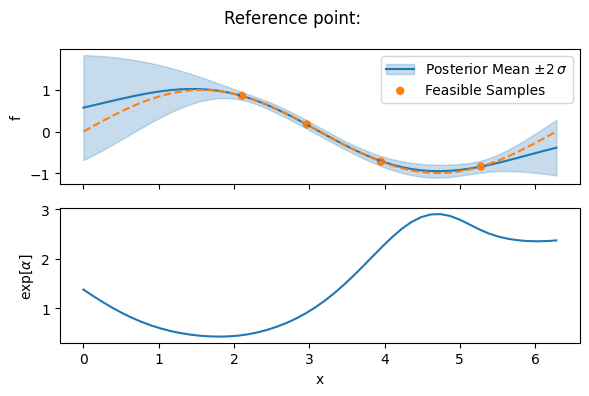

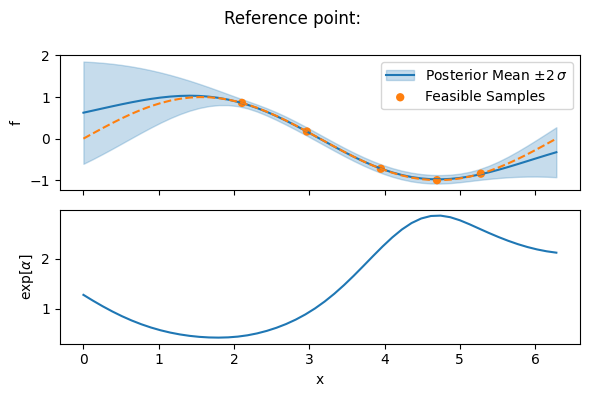

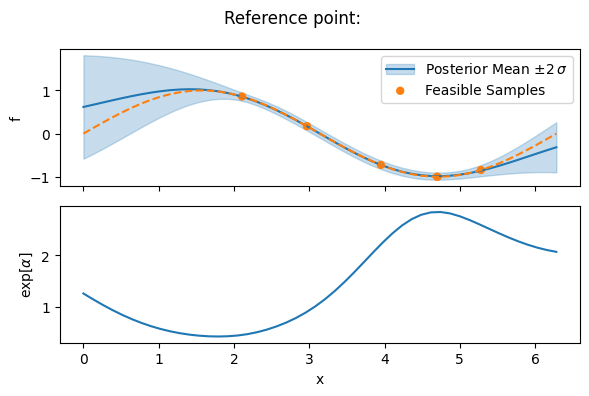

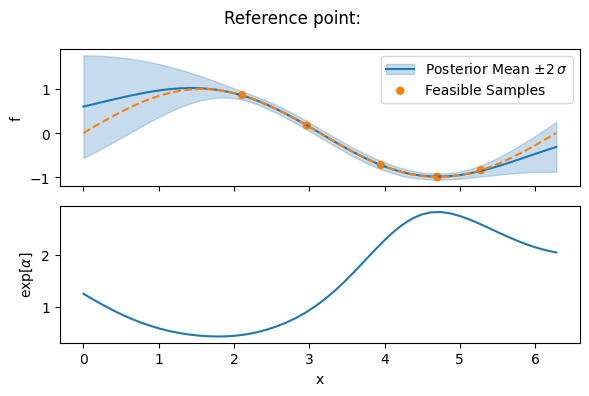

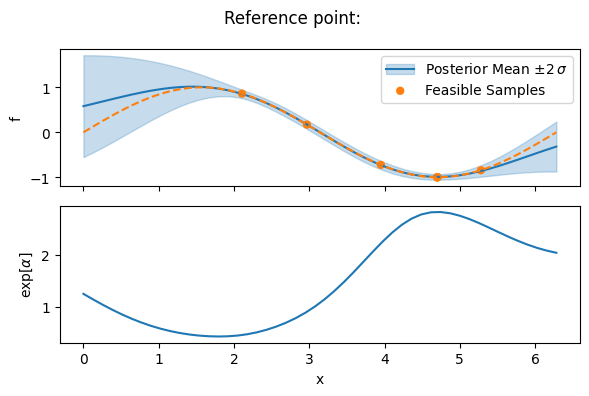

In [5]:
n_steps = 5

# test points for plotting
test_x = np.linspace(*np.array(X.vocs.bounds).flatten(), 50)

for i in range(n_steps):
    # get the Gaussian process model from the generator
    model = X.generator.train_model()

    # visualize model
    fig, ax = X.generator.visualize_model(n_grid=len(test_x))

    # plot true function
    true_f = sin_function({"x": test_x})["f"]
    ax[0, 0].plot(test_x, true_f, "C1--")

    # do the optimization step
    X.step()

In [6]:
# access the collected data
X.data

,x,f,f_var,xopt_runtime,xopt_error
0,2.969196,0.171544,0.002969,0.000011,False
1,5.281023,-0.842637,0.005281,0.000003,False
2,2.106419,0.859951,0.002106,0.000001,False
3,3.951739,-0.724388,0.003952,0.000002,False
4,4.697807,-0.999894,0.004698,0.000006,False
5,4.702834,-0.999954,0.004703,0.000007,False
6,4.703303,-0.999959,0.004703,0.000007,False
7,4.702694,-0.999953,0.004703,0.000007,False
8,4.701636,-0.999942,0.004702,0.000007,False


## Getting the optimization result
To get the best point (without evaluating it) we ask the generator to
predict the optimum based on the posterior mean.

In [7]:
X.generator.get_optimum()

,x
0,4.707853


## Customizing optimization
Each generator has a set of options that can be modified to effect optimization behavior

In [8]:
X.generator.dict()

/tmp/ipykernel_3456/1542263183.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  X.generator.dict()


{'returns_id': False,
 'supports_single_objective': True,
 'supports_constraints': True,
 'vocs': {'variables': {'x': {'dtype': None,
    'default_value': None,
    'domain': [0.0, 6.283185307179586],
    'type': 'ContinuousVariable'}},
  'objectives': {'f': {'dtype': None, 'type': 'MinimizeObjective'}},
  'constraints': {},
  'constants': {},
  'observables': {}},
 'model': ModelListGP(
   (models): ModuleList(
     (0): XoptHeteroskedasticSingleTaskGP(
       (likelihood): _GaussianLikelihoodBase(
         (noise_covar): HeteroskedasticNoise(
           (noise_model): SingleTaskGP(
             (likelihood): GaussianLikelihood(
               (noise_covar): HomoskedasticNoise(
                 (noise_prior): SmoothedBoxPrior()
                 (raw_noise_constraint): GreaterThan(1.000E-04)
               )
             )
             (mean_module): ConstantMean()
             (covar_module): RBFKernel(
               (lengthscale_prior): LogNormalPrior()
               (raw_lengthsca